In [2]:
import scanpy as sc
import sys
sys.path.append(r"D:\Scunpair_Project\Diagonal-integration")
import mycode
adata = sc.read_h5ad(r"D:\Scunpair_Project\Benchmark_result(strong)\MaxFuse\unpaired\Muto-2021\coembed_multi.h5ad")

c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


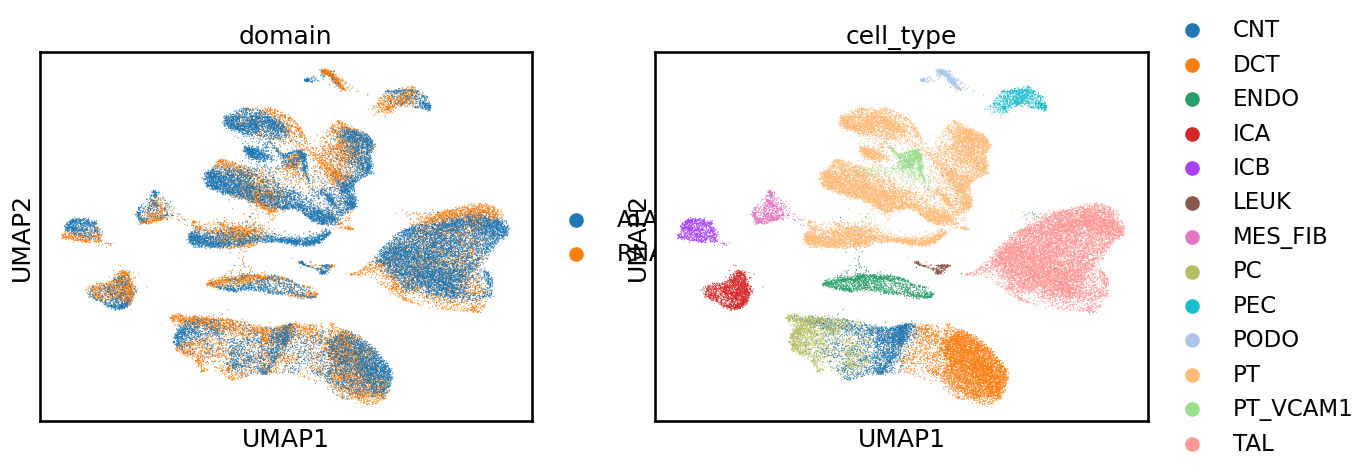

In [3]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['domain','cell_type'])

In [4]:
rna_integrated = adata[:6408]
atac_integrated = adata[6408:]

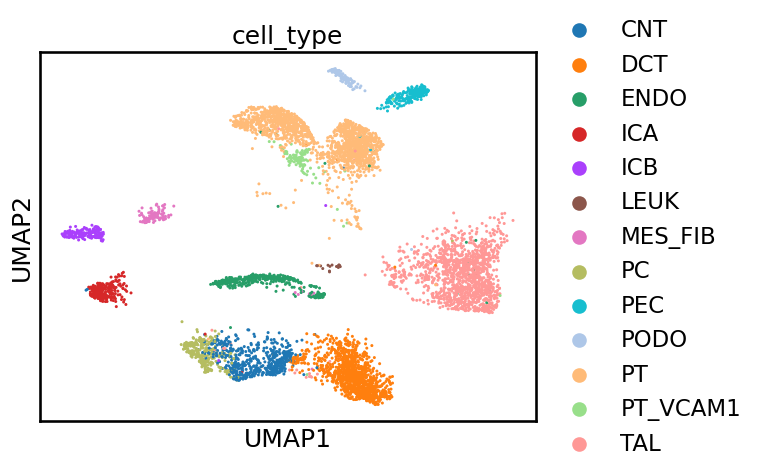

In [5]:
sc.pl.umap(rna_integrated, color=['cell_type'])

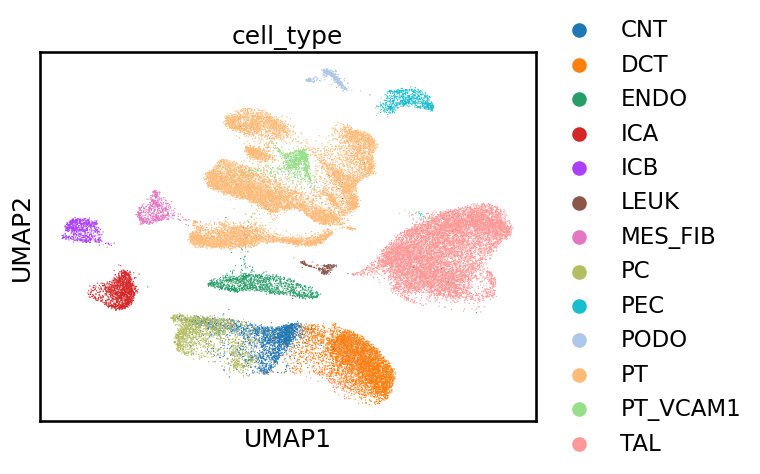

In [6]:
sc.pl.umap(atac_integrated, color=['cell_type'])

In [7]:
adata.obsm['X_emb'] = adata.X
acc, f1 = mycode.metrics.calculate_shared_type_transfer_metrics(adata, batch_key='domain', label_key='cell_type', embed="X_emb")

from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
adata.obsm['X_emb'] = adata.X
%matplotlib inline
bm = Benchmarker(
    adata,
    batch_key="domain",
    label_key="cell_type",
    bio_conservation_metrics=BioConservation(silhouette_label=False),
    batch_correction_metrics=BatchCorrection(pcr_comparison=False),
    embedding_obsm_keys=["X_umap", "X_emb"],
    n_jobs=6,
)
bm.benchmark()

c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\scanpy\preprocessing\_pca\__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
Embeddings:   0%|          | 0/2 [00:00<?, ?it/s]c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\scib_metrics\metrics\_kbet.py:182: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  idx_nonan = np.flatnonzero(np.in1d(labs, comp_size[comp_size >= comp_size_thresh].index))
c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\scib_metrics\metrics\_kbet.py:182: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  idx_nonan = np.flatnonzero(np.in1d(labs, comp_size[comp_size >= comp_size_thresh].index))
c:\Users\Administrator\miniconda3\envs\mycode\lib\sit

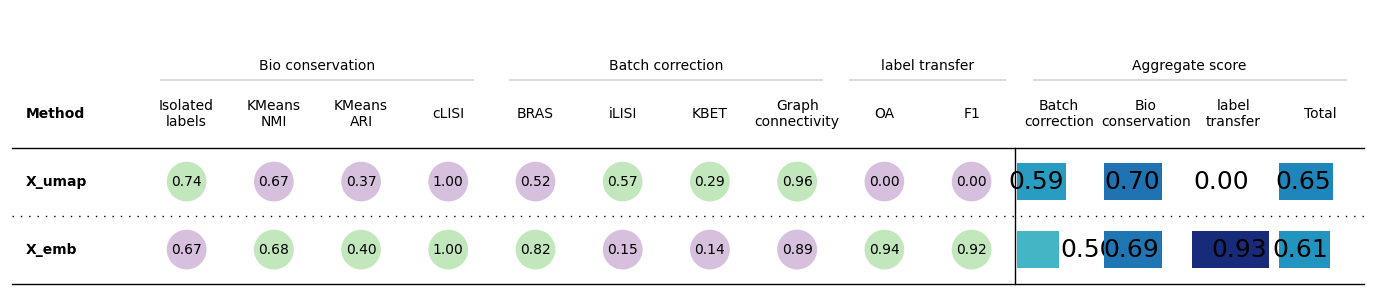

In [8]:
bm._results.loc['OA'] = {
    "X_umap": 0.0,
    "X_emb": acc,
    "Metric Type": "label transfer"
}
bm._results.loc['F1'] = {
    "X_umap": 0.0,
    "X_emb": f1,
    "Metric Type": "label transfer"
}
bm.plot_results_table(min_max_scale=False)